# Name: Peter Mangoro


# Pima Indians Diabetes (classification case study)

 In this notebook I load the Pima Indians Diabetes data, explore it, build and validate two supervised classifiers, document how I avoid leakage, and end with PCA/K-means.



## Setup and ingest

- **Dataset:** Pima Indians Diabetes Database (female patients, age ≥ 21, Pima Indian heritage).
- **File:** `diabetes.csv` in the same folder as this notebook (`assignments/GDP/`).
- **Target:** `Outcome` (1 = diabetes, 0 = no diabetes).


In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 9
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

sns.set_theme(context="notebook", style="whitegrid")

In [36]:
DATA_PATH = Path("diabetes.csv")
assert DATA_PATH.is_file(), f"Missing {DATA_PATH.resolve()} — place diabetes.csv next to this notebook."

df = pd.read_csv(DATA_PATH)

assert df.shape == (768, 9), f"Expected (768, 9), got {df.shape}"

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.info()

Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## Data overview

I check for duplicate rows, numeric summaries via `describe`, and I store the list of predictor columns (`feature_cols`) separate from the target `Outcome`.


In [39]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

df.describe(include=np.number)


Duplicate rows: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [40]:
TARGET = "Outcome"
feature_cols = [c for c in df.columns if c != TARGET]
assert len(feature_cols) == 8
feature_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

### Interpretation

From `df.info()` and `describe()` , I confirm **768** complete rows and **no explicit NaNs** in the CSV. At the same time, several clinical variables (**Glucose**, **BloodPressure**, **SkinThickness**, **Insulin**, **BMI**) show **minimum values of 0**, which are unlikely to be real measurements so I treat many zeros as **missingness in disguise**. The target mean for `Outcome` (about **0.35**) matches a **mild imbalance** (~35% diabetic vs ~65% non-diabetic), which tells me I should not rely on accuracy alone later and should emphasize **ROC-AUC** and **F1 / precision–recall** under **stratified** validation. The quartiles also show heavy **zero mass** for **SkinThickness** and especially **Insulin**, and **Insulin** has a wide spread and a large maximum, so I expect skew and possibly influential points. These observations motivate  a **leakage-safe pipeline** that recodes selected zeros to **NaN**, **imputes inside training folds**, and compares an **interpretable linear** model with a **more flexible** nonlinear one.


## Outcome imbalance and clinical zero audit

I tabulate **`Outcome`** counts and proportions and plot a bar chart. Then I measure how often selected clinical columns equal **0**, treating those zeros as likely invalid or missing .I **do not** apply this logic to **`Pregnancies`**, where 0 can be valid.


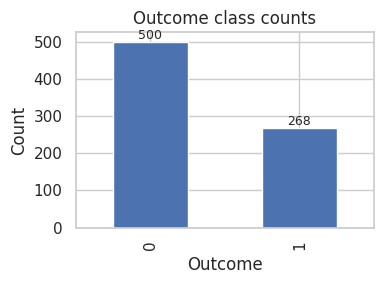

,count,proportion
Outcome,,
0,500,0.651042
1,268,0.348958


In [41]:
# Outcome class counts and proportions
outcome_counts = df[TARGET].value_counts().sort_index()
outcome_props = df[TARGET].value_counts(normalize=True).sort_index()

summary_outcome = (
    pd.DataFrame({"count": outcome_counts, "proportion": outcome_props})
    .rename_axis(index=TARGET)
)

fig, ax = plt.subplots(figsize=(4, 3))
summary_outcome["count"].plot(kind="bar", ax=ax)
ax.set_title("Outcome class counts")
ax.set_xlabel("Outcome")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
plt.show()

summary_outcome

### Interpretation: Class Balance

From the table and bar chart above, I see roughly **two-thirds** non-diabetic and **one-third** diabetic patients, which is a **moderate imbalance**. A naive classifier that always predicts the majority class would already reach about **65% accuracy**, so **accuracy alone** would flatter a weak model. I will use **stratified** train/test splitting and **stratified k-fold CV**, and I will report **ROC-AUC**, **F1**, **precision**, and **recall** so performance on the **diabetic** class is visible.


### Clinical zero audit

I count zeros in each listed clinical column and express them as a fraction of all rows. Large percentages strengthen the case for treating zeros as **missing** for those variables .


In [43]:
# Clinical zeros in measurements where 0 is likely invalid / missing
CLINICAL_ZERO_AS_NA = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

zero_stats = []
for col in CLINICAL_ZERO_AS_NA:
    n_zero = (df[col] == 0).sum()
    pct_zero = n_zero / len(df)
    zero_stats.append({"column": col, "n_zero": n_zero, "pct_zero": pct_zero})

zero_table = pd.DataFrame(zero_stats).set_index("column")
zero_table["pct_zero"] = zero_table["pct_zero"].round(3)

print("Clinical zero audit (0 likely means missing/invalid measurement):")



zero_table

Clinical zero audit (0 likely means missing/invalid measurement):


,n_zero,pct_zero
column,,
Glucose,5,0.007
BloodPressure,35,0.046
SkinThickness,227,0.296
Insulin,374,0.487
BMI,11,0.014


### Interpretation: clinical zeros

The table shows that implausible zeros concentrate in **Insulin** and **SkinThickness**, with smaller but nontrivial rates in **BloodPressure**, **BMI**, and **Glucose**. That pattern supports my decision to mark **0 → NaN** for those five measurements while leaving **`Pregnancies`** at zero when reported. Later I will **impute** inside a **`Pipeline`** fit on training folds only and continue to emphasize **ROC-AUC** and **F1** rather than raw accuracy.


## Distributions of predictor variables


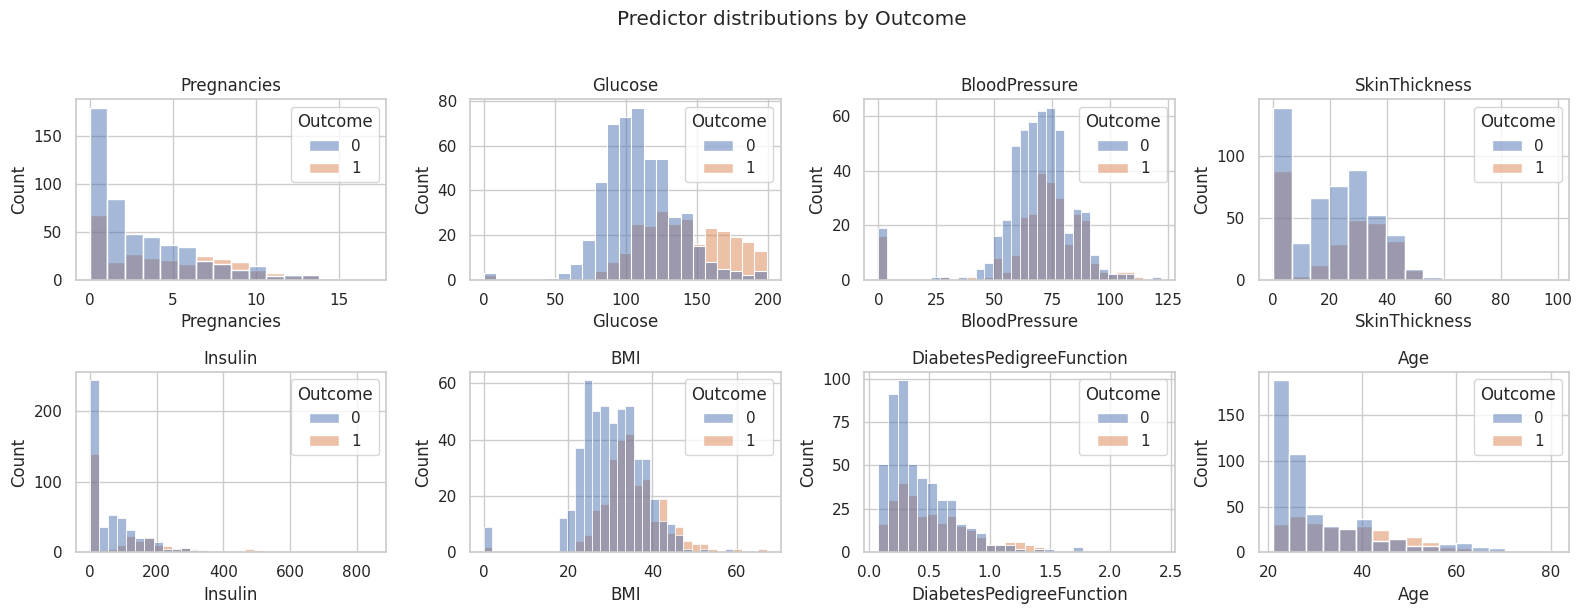

In [44]:
# Histograms for all predictors
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    sns.histplot(data=df, x=col, hue=TARGET, multiple="layer", stat="count", kde=False, ax=ax)
    ax.set_title(col)

# Turn off any unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle("Predictor distributions by Outcome", y=1.02)
fig.tight_layout()
plt.show()

### Interpretation: predictor distributions

Visually, **Glucose** shifts **right** for diabetic cases, so it is a strong **univariate** signal. **BMI** and **Age** also show moderate separation, while **BloodPressure** overlaps more between classes. **Pregnancies** and **DiabetesPedigreeFunction** are **right-skewed** with heavier tails among diabetics, which suggests they may help but not through a simple linear split. **SkinThickness** and especially **Insulin** show a **spike at zero**, consistent with my zero audit—those need careful handling rather than literal zeros. No single feature fully separates the classes, so I expect **multivariate** models to matter, and I still want both a **linear** baseline and a **nonlinear** comparator in Phase 3.


## Phase 2d — Correlations among predictors

I compute the Pearson correlation matrix for the eight predictors and visualize it with a heatmap to spot **redundancy** and **multicollinearity** before fitting linear models.


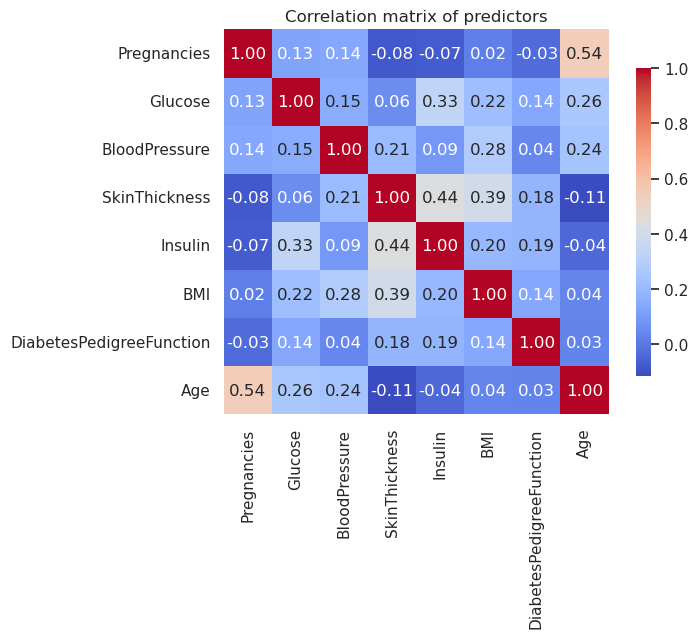

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


In [9]:
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix of predictors")
# fig.tight_layout()
plt.show()

corr_matrix

### Interpretation: correlations

Correlations are mostly **weak-to-moderate**; nothing approaches extreme multicollinearity (e.g. ±0.9). The strongest positive association is **Pregnancies–Age** (about **0.54**), which is clinically plausible and suggests some **redundancy** for linear models. **Insulin–SkinThickness** and **BMI–SkinThickness** move together moderately, and **Glucose–Insulin** is a moderate positive pair. **BloodPressure–BMI** is only mild-to-moderate. Negative linear associations are small. Overall, predictors are related but not so collinear that logistic regression is inappropriate; I still want **regularized / balanced** logistic regression and a **nonlinear** model because **correlation does not capture interactions or curvature**.


## Phase 2e — How my EDA drives modeling choices

- **Class balance:** I will use **stratified** splitting and CV and report **ROC-AUC** and **F1 / precision–recall** (not accuracy alone), because the majority class dominates the baseline accuracy.

- **Invalid clinical zeros:** I will recode zeros to **NaN** for **Glucose**, **BloodPressure**, **SkinThickness**, **Insulin**, and **BMI** only, then **impute inside training folds** via **`Pipeline`**. **`Pregnancies = 0`** stays valid.

- **Skew and tails:** **Insulin** is strongly right-skewed (large max in `describe`); **SkinThickness** also shows zero inflation/skew. That pushes me toward **robust preprocessing** (median impute, scaling for logistic regression) and comparing **linear** vs **nonlinear** models.

- **Correlations:** Mostly moderate (e.g. **Pregnancies–Age** strongest). I will interpret linear coefficients cautiously and still use a **nonlinear** benchmark.

- **Leakage guardrail:** Every learned preprocessing step (**impute**, **scale**, later **PCA**) must **fit only on training data** (per fold in CV), so validation and test metrics stay **honest**.


## Phase 3 — Supervised modeling and validation (Tasks 2–3)

I now move from EDA to supervised modeling with an explicit **leakage-safe** design: every learned preprocessing step stays inside **`Pipeline`** objects and is fit on **training data only** (per CV fold or on the full training split before the final test evaluation).

In Phases 3–6 I complete:

- **Phase 3a:** supervised inputs (`X`, `y`) + zero-as-missing policy.
- **Phase 3b:** stratified train/test split and stratified CV configuration.
- **Phase 3c:** leakage-safe preprocessing embedded in model `Pipeline`s.
- **Phase 3d–3e:** stratified cross-validation on the training split, comparison table, and model selection.
- **Phase 3f:** refit the selected pipeline on **all** training data; **one** held-out evaluation on the test set (metrics + confusion matrix / ROC).
- **Phase 3g:** why ROC-AUC, F1, precision, and recall suit this imbalanced clinical setting, and how CV vs test roles differ.
- **Phase 4:** data leakage investigation (Task 4): split order, in-pipeline learning (impute/scale/model), no global scaling on pooled train+test, and no target-derived predictors.
- **Phase 5:** unsupervised representation (Task 5): PCA structure + K-means in PC space; PCA inside `Pipeline` for CV vs raw-feature baselines.
- **Phase 6:** Canvas research summary (**≤ 500 characters**) with automated length check.

### Phase 3a — Create supervised inputs and zero-as-missing policy

I build **`X`** (eight predictors) and **`y`** (`Outcome`). I keep **`Pregnancies`** unchanged because **0** can mean “no prior pregnancies.” For **Glucose**, **BloodPressure**, **SkinThickness**, **Insulin**, and **BMI**, I cast to float and replace **0** with **`NaN`**, matching my Phase 2 audit. In the next cell I print shapes, class prevalence, missingness rates after recoding, and a compact **before/after** `describe` table for those columns.

In [10]:
from sklearn.model_selection import StratifiedKFold, train_test_split

TARGET = "Outcome"
FEATURES = [c for c in df.columns if c != TARGET]

CLINICAL_ZERO_AS_MISSING = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Make selected columns NaN-compatible, then mark implausible clinical zeros as missing.
X[CLINICAL_ZERO_AS_MISSING] = X[CLINICAL_ZERO_AS_MISSING].astype("float64")
X[CLINICAL_ZERO_AS_MISSING] = X[CLINICAL_ZERO_AS_MISSING].mask(
    X[CLINICAL_ZERO_AS_MISSING] == 0,
    np.nan,
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass prevalence (full dataset):")
print(y.value_counts(normalize=True).sort_index().rename("proportion"))

missing_after_zero_policy = X[CLINICAL_ZERO_AS_MISSING].isna().mean().round(3)
print("\nMissing rate after zero->NaN policy:")
print(missing_after_zero_policy)

before = df[CLINICAL_ZERO_AS_MISSING].describe().T[["count", "mean", "50%", "min"]].add_prefix("before_")
after = X[CLINICAL_ZERO_AS_MISSING].describe().T[["count", "mean", "50%", "min"]].add_prefix("after_")
compare = before.join(after)
compare["n_missing_after"] = X[CLINICAL_ZERO_AS_MISSING].isna().sum()

print("\nCompact before/after comparison:")
compare

X shape: (768, 8)
y shape: (768,)

Class prevalence (full dataset):
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Missing rate after zero->NaN policy:
Glucose          0.007
BloodPressure    0.046
SkinThickness    0.296
Insulin          0.487
BMI              0.014
dtype: float64

Compact before/after comparison:


,before_count,before_mean,before_50%,before_min,after_count,after_mean,after_50%,after_min,n_missing_after
Glucose,768.0,120.894531,117.0,0.0,763.0,121.686763,117.0,44.0,5
BloodPressure,768.0,69.105469,72.0,0.0,733.0,72.405184,72.0,24.0,35
SkinThickness,768.0,20.536458,23.0,0.0,541.0,29.153420,29.0,7.0,227
Insulin,768.0,79.799479,30.5,0.0,394.0,155.548223,125.0,14.0,374
BMI,768.0,31.992578,32.0,0.0,757.0,32.457464,32.3,18.2,11


### Interpretation: supervised inputs and zero→NaN policy

After running the cell above, I verify that **`X`** has shape **(768, 8)** and **`y`** has shape **(768,)**, with class proportions still near **65% / 35%**. The missing-rate line confirms that **Insulin** and **SkinThickness** carry the most **NaN**s after recoding—consistent with the zero audit. The **before/after** table shows **minimums** are no longer **0** on those clinical columns, and **means/medians** rise where many zeros were masking missing values (especially **Insulin**). That supports my choice to impute later **inside** a **`Pipeline`** rather than treating zeros as real measurements.

### Phase 3b — Stratified split and CV configuration

I hold out **20%** of the rows as a **stratified** test set (`X_test`, `y_test`) so class proportions match the full data. On the remaining **80%** (`X_train`, `y_train`) I run **5-fold stratified CV** via a shared `StratifiedKFold` object (`cv`) for every model comparison. I set **`RANDOM_STATE = 42`** for reproducibility.

In [11]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nClass proportion by split:")
print(
    pd.DataFrame(
        {
            "full": y.value_counts(normalize=True).sort_index(),
            "train": y_train.value_counts(normalize=True).sort_index(),
            "test": y_test.value_counts(normalize=True).sort_index(),
        }
    ).round(3)
)

print("\nCV config:", cv)

Train shape: (614, 8) | Test shape: (154, 8)

Class proportion by split:
          full  train   test
Outcome                     
0        0.651  0.651  0.649
1        0.349  0.349  0.351

CV config: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### Phase 3c — Leakage-safe preprocessing and model pipelines

I wrap all preprocessing in **`Pipeline`** objects so each CV fold fits **median imputation** (and **standardization** for logistic regression) on **fold-train rows only**.

I compare two models on equal footing:

1. **Logistic regression** — interpretable linear baseline; needs **scaling** after imputation.
2. **Random forest** — nonlinear ensemble; I still **impute** inside the pipeline but **omit** scaling (tree splits are scale-invariant).

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic regression pipeline: impute + scale + model
logreg_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                solver="liblinear",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Random forest pipeline: impute + model (no scaling required)
rf_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

model_pipelines = {
    "LogisticRegression": logreg_pipeline,
    "RandomForest": rf_pipeline,
}

print("Pipelines defined:", list(model_pipelines.keys()))
for name, pipe in model_pipelines.items():
    print(f"\n{name} steps: {list(pipe.named_steps.keys())}")

Pipelines defined: ['LogisticRegression', 'RandomForest']

LogisticRegression steps: ['imputer', 'scaler', 'model']

RandomForest steps: ['imputer', 'model']


**Checkpoint:** I expect `model_pipelines` to list **`LogisticRegression`** and **`RandomForest`**, each bundling imputation (and scaling for logistic) with the estimator. I will pass the same **`cv`** and **`X_train` / `y_train`** into `cross_validate` next.

### Phase 3d — Cross-validated evaluation (training data only)

I run **`cross_validate`** on **`X_train` / `y_train`** with the shared **`cv`** object and several metrics (**ROC-AUC**, **F1**, **precision**, **recall**, **accuracy**). Each fold refits the full **`Pipeline`**, so validation scores are not contaminated by fold-validation rows. I then plot **CV mean ± std** for **ROC-AUC** and draw **out-of-fold** ROC curves using **`cross_val_predict`** (probabilities) for both models.


=== LogisticRegression ===
  roc_auc       mean=0.8443  std=0.0160
  f1            mean=0.6724  std=0.0133
  precision     mean=0.6486  std=0.0263
  recall        mean=0.7010  std=0.0395
  accuracy      mean=0.7622  std=0.0111

=== RandomForest ===
  roc_auc       mean=0.8250  std=0.0269
  f1            mean=0.6296  std=0.0324
  precision     mean=0.7009  std=0.0648
  recall        mean=0.5748  std=0.0341
  accuracy      mean=0.7638  std=0.0258


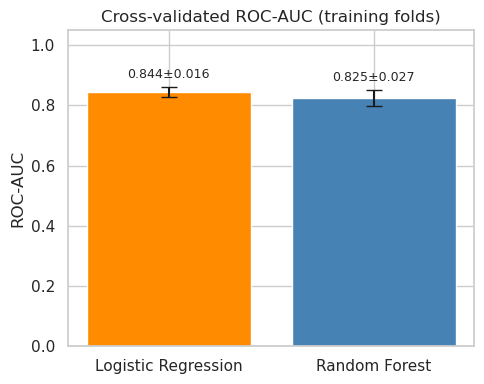

In [13]:
from sklearn.model_selection import cross_validate

SCORING = ["roc_auc", "f1", "precision", "recall", "accuracy"]

# Shared colors for model comparison plots (bar chart + ROC curves)
MODEL_COLORS = {"LogisticRegression": "darkorange", "RandomForest": "steelblue"}

cv_results_raw = {}
for name, pipe in model_pipelines.items():
    cv_results_raw[name] = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False,
    )

for name in model_pipelines:
    print(f"\n=== {name} ===")
    for m in SCORING:
        key = f"test_{m}"
        vals = cv_results_raw[name][key]
        print(f"  {m:12s}  mean={vals.mean():.4f}  std={vals.std():.4f}")

# Visual: ROC-AUC only — Logistic Regression vs Random Forest
roc_order = ["LogisticRegression", "RandomForest"]
roc_labels = {
    "LogisticRegression": "Logistic Regression",
    "RandomForest": "Random Forest",
}
present = [k for k in roc_order if k in cv_results_raw]
if present:
    means = [cv_results_raw[k]["test_roc_auc"].mean() for k in present]
    stds = [cv_results_raw[k]["test_roc_auc"].std() for k in present]
    labels = [roc_labels.get(k, k) for k in present]

    fig, ax = plt.subplots(figsize=(5, 4))
    x = np.arange(len(present))
    ax.bar(x, means, yerr=stds, capsize=6, color=[MODEL_COLORS[k] for k in present])
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(0, 1.05)
    ax.set_title("Cross-validated ROC-AUC (training folds)")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, min(m + s + 0.03, 1.02), f"{m:.3f}±{s:.3f}", ha="center", fontsize=9)
    fig.tight_layout()
    plt.show()

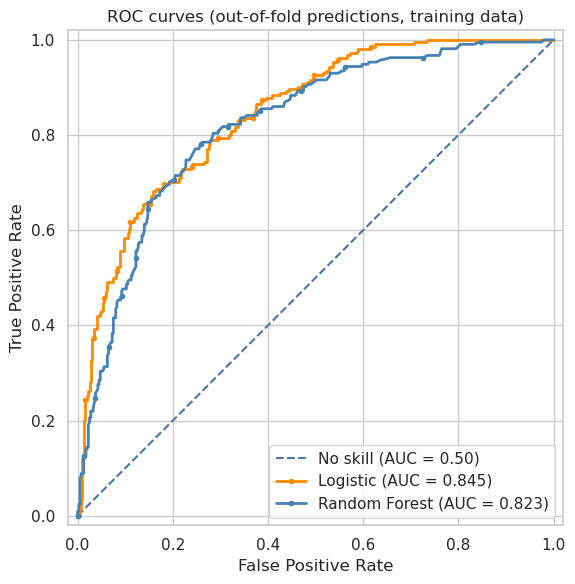

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

# Classic ROC plot (TPR vs FPR): out-of-fold scores on training data — same folds as CV, no test leakage
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "b--", lw=1.5, label="No skill (AUC = 0.50)")

curve_labels = [
    ("LogisticRegression", "Logistic"),
    ("RandomForest", "Random Forest"),
]
for key, label in curve_labels:
    if key not in model_pipelines:
        continue
    color = MODEL_COLORS[key]
    y_proba = cross_val_predict(
        model_pipelines[key],
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    roc_auc = auc(fpr, tpr)
    n_pts = len(fpr)
    markevery = max(1, n_pts // 15)
    ax.plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        marker="o",
        markersize=3,
        markevery=markevery,
        label=f"{label} (AUC = {roc_auc:.3f})",
    )

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves (out-of-fold predictions, training data)")
ax.legend(loc="lower right")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

### Interpretation: CV metrics and training ROC curves

From the printed fold metrics and the **ROC-AUC** bar chart, I compare **variability** across folds (error bars) as well as the **mean** score. The **out-of-fold ROC** plot shows how each model ranks positives vs negatives on training data **without** using the held-out test set. If **logistic regression** sits higher, I read that as stronger **ranking** performance on this split; I still treat **test-set** evaluation in Phase 3f as the single **honest** snapshot for reporting generalization.

### Phase 3e — Comparison table and model selection

I summarize **`cross_validate`** results in tables (raw means/stds and a formatted **mean ± std** view). Because of class imbalance (~65/35), I **select** the best pipeline by **highest mean ROC-AUC** on the training CV, using **mean F1** as a **tie-breaker**—not raw accuracy. I store **`best_model_name`** and **`best_pipeline`** for Phase 3f.

In [15]:
rows = []
for name in model_pipelines:
    row = {"model": name}
    for m in SCORING:
        key = f"test_{m}"
        vals = cv_results_raw[name][key]
        row[f"{m}_mean"] = vals.mean()
        row[f"{m}_std"] = vals.std()
    rows.append(row)

cv_metrics_df = pd.DataFrame(rows).set_index("model")
display(cv_metrics_df.round(4))

fmt_rows = []
for name in model_pipelines:
    fmt_row = {"model": name}
    for m in SCORING:
        mean = cv_results_raw[name][f"test_{m}"].mean()
        std = cv_results_raw[name][f"test_{m}"].std()
        fmt_row[m] = f"{mean:.3f} ± {std:.3f}"
    fmt_rows.append(fmt_row)

cv_summary_fmt = pd.DataFrame(fmt_rows).set_index("model")
print("CV summary (mean ± std):")
display(cv_summary_fmt)

# Selection: maximize ROC-AUC, then F1 as tie-breaker
best_model_name = max(
    model_pipelines.keys(),
    key=lambda n: (
        cv_results_raw[n]["test_roc_auc"].mean(),
        cv_results_raw[n]["test_f1"].mean(),
    ),
)
best_pipeline = model_pipelines[best_model_name]

print(
    f"\nSelected model (CV): {best_model_name}\n"
    f"  ROC-AUC mean: {cv_results_raw[best_model_name]['test_roc_auc'].mean():.4f}\n"
    f"  F1 mean:      {cv_results_raw[best_model_name]['test_f1'].mean():.4f}"
)

,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,accuracy_mean,accuracy_std
model,,,,,,,,,,
LogisticRegression,0.8443,0.0160,0.6724,0.0133,0.6486,0.0263,0.7010,0.0395,0.7622,0.0111
RandomForest,0.8250,0.0269,0.6296,0.0324,0.7009,0.0648,0.5748,0.0341,0.7638,0.0258


CV summary (mean ± std):


,roc_auc,f1,precision,recall,accuracy
model,,,,,
LogisticRegression,0.844 ± 0.016,0.672 ± 0.013,0.649 ± 0.026,0.701 ± 0.039,0.762 ± 0.011
RandomForest,0.825 ± 0.027,0.630 ± 0.032,0.701 ± 0.065,0.575 ± 0.034,0.764 ± 0.026



Selected model (CV): LogisticRegression
  ROC-AUC mean: 0.8443
  F1 mean:      0.6724


### Interpretation: which model I select on CV

From the tables and printed **`best_model_name`**, I see which pipeline wins under my **ROC-AUC-first** rule. I keep in mind that CV means are **estimates** with uncertainty (std across folds); if two models are close, I also glance at **F1** and **precision/recall** before I refit the winner on the full training set in Phase 3f.

### Phase 3f — Refit on full training data; single held-out test evaluation

CV (Phases 3d–3e) used only **`X_train` / `y_train`** to pick **`best_pipeline`**. I now **`fit`** that pipeline **once** on **all** training rows and evaluate **once** on **`X_test` / `y_test`**—I do **not** tune thresholds or hyperparameters on the test set. That single test report is my best **honest** estimate of how the chosen pipeline would behave on new patients drawn like this cohort.

Held-out test ROC-AUC — LogisticRegression: 0.8126

Classification report (test; positive label = diabetes):
                 precision    recall  f1-score   support

No diabetes (0)      0.824     0.750     0.785       100
   Diabetes (1)      0.603     0.704     0.650        54

       accuracy                          0.734       154
      macro avg      0.714     0.727     0.717       154
   weighted avg      0.747     0.734     0.738       154



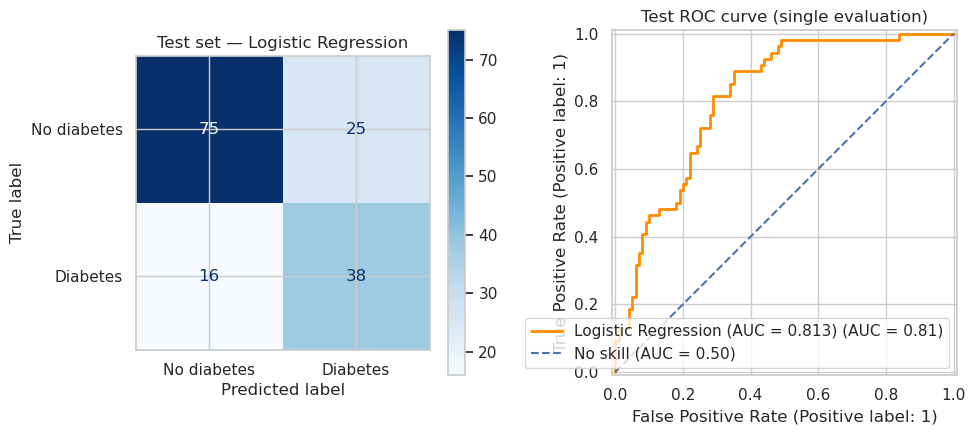

In [16]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)

best_pipeline.fit(X_train, y_train)

y_test_pred = best_pipeline.predict(X_test)
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"Held-out test ROC-AUC — {best_model_name}: {test_roc_auc:.4f}\n")

print("Classification report (test; positive label = diabetes):")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No diabetes (0)", "Diabetes (1)"],
        digits=3,
    )
)

best_plot_label = {
    "LogisticRegression": "Logistic Regression",
    "RandomForest": "Random Forest",
}.get(best_model_name, best_model_name)
line_color = MODEL_COLORS.get(best_model_name, "C0")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Blues",
    ax=axes[0],
    colorbar=True,
)
axes[0].set_title(f"Test set — {best_plot_label}")

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=f"{best_plot_label} (AUC = {test_roc_auc:.3f})",
    ax=axes[1],
    curve_kwargs={"color": line_color, "linewidth": 2},
)
axes[1].plot([0, 1], [0, 1], "b--", lw=1.5, label="No skill (AUC = 0.50)")
axes[1].set_title("Test ROC curve (single evaluation)")
axes[1].legend(loc="lower right")
axes[1].set_aspect("equal", adjustable="box")

fig.tight_layout()
plt.show()

### Interpretation: held-out test performance

I read the printed **test ROC-AUC**, **classification report**, and the **confusion matrix / ROC** figure together. **ROC-AUC** summarizes ranking quality on truly unseen rows; the **confusion matrix** shows whether I am missing many diabetics (**false negatives**) or alarming too many healthy patients (**false positives**) at the default **0.5** cutoff. I compare this single test snapshot to CV means knowing the test set is modest in size (**~154** rows).

### Phase 3g — Why I report these metrics for imbalanced clinical data

**Class imbalance:** With about **65%** non-diabetic and **35%** diabetic, a naive majority-class rule already reaches ~**65% accuracy**, so **accuracy alone** can hide poor detection of diabetes. I therefore emphasize **ROC-AUC** and **class-wise** scores.

**ROC-AUC** measures how well predicted **risk ranks** positives above negatives **across thresholds**, which suits moderate imbalance and future threshold tuning (e.g. screening vs confirmatory care).

**Precision, recall, and F1** (at sklearn’s default **0.5** cutoff from `predict`) tell me how the model behaves at a **fixed** operating point: **recall** is the fraction of diabetics caught; **precision** is how often a positive alarm is correct; **F1** balances the two. The **confusion matrix** in Phase 3f makes **false negatives vs false positives** concrete.

**CV vs test:** **K-fold CV** on the training split quantifies **variability** and supports **model choice** without touching the test labels. My **one** Phase **3f** test evaluation is **not** for tuning; if CV and test disagree slightly, I attribute some of that to **noise** on a **~20%** holdout and read both together.

## Phase 4 — Data leakage investigation (Task 4)

[assignment2.md](assignment2.md) asks me to audit leakage from **(i)** preprocessing before splitting, **(ii)** scaling or imputation fit on the **entire** dataset (train+test pooled), and **(iii)** **target leakage** through feature construction—and to explain how **my** workflow stays honest. I map each risk to the steps I already implemented (Phases **3a–3c**, **3d**, and **3f**). Background: [W8_Model-Evaluation-Validation-and-Data-Leakage_Beginner_Guide.md](../../W8_Model-Evaluation-Validation-and-Data-Leakage_Beginner_Guide.md).

### Where I allow information to flow

My supervised workflow is: build **`X`** and **`y`** → **stratified train/test split** → **`fit`** preprocessing and models on **training** data only (or on each **CV training fold**) → **evaluate** on the validation fold or the final **test** set. I never use test-row values to learn imputation medians, scaling means/variances, PCA directions, or model coefficients during those fits.

```mermaid
flowchart LR
  rawData[Raw_df_and_EDA]
  xy[Build_X_and_y]
  split[Stratified_train_test_split]
  trainFit[Fit_Pipeline_on_train_or_CV_train_fold]
  evalStep[Predict_on_val_or_test_only]
  rawData --> xy --> split --> trainFit --> evalStep
```

### Preprocessing relative to the split

- **Stratified split first:** I create **`X_train` / `X_test`** in Phase **3b** before any **`Pipeline.fit`** that learns from both halves together.
- **Zero → NaN (Phase 3a)** happens on **`X` before** that split. I treat that as a **fixed clinical rule** (invalid zeros for Glucose, BloodPressure, SkinThickness, Insulin, BMI—not for Pregnancies). It does **not** use **`Outcome`** or test-set statistics. Anything **learned from data**—medians, means/variances, model weights—lives in the **`Pipeline`** and is fit on **`X_train`** (or on **CV train folds** only in Phases **3d–3e** and the training ROC figure).

### Why I do not “scale the whole dataset”

A common mistake is fitting **`StandardScaler`** or **`SimpleImputer`** on **all rows** (or `pd.concat([X_train, X_test])`), letting the **test** distribution shape training features. That **inflates** metrics.

In my notebook, **`StandardScaler`** sits **inside** the logistic **`Pipeline`** only; its **`fit`** sees **train-fold** data in CV and **`X_train`** for the final refit—**not** **`X_test`**. Random forest uses the same **imputer-in-pipeline** pattern without a global scaler. I never fit preprocessing on the full **768** rows and **then** split.

### Target leakage

I build inputs from **`FEATURES`** (all columns except **`Outcome`**), so the label never enters **`X`** as a predictor. I do not engineer features from **`Outcome`**. **`DiabetesPedigreeFunction`** is an external pedigree score bundled with the table—not a function of the realized label—so I do not treat it as target leakage.

**Summary:** I used the full **`df`** only for **EDA**; **evaluation** relies on a **held-out test** set and **fold-wise** fitting in CV. Keeping learned steps inside **`Pipeline`** plus disciplined splits is how I **address** the rubric’s leakage checklist.

**Programmatic check:** In the next cell I assert that **`TARGET`** is absent from **`X`**, **`X_train`**, and **`X_test`** and that column names align across splits.

In [17]:
# Phase 4 — quick assertions (run after Phase 3a–3b define X, X_train, X_test)
assert TARGET not in X.columns, "Target must not appear as a feature column."
assert TARGET not in X_train.columns and TARGET not in X_test.columns
assert list(X_train.columns) == list(X_test.columns)
print("OK — I verified the target is not a feature column and train/test columns match.")

OK — I verified the target is not a feature column and train/test columns match.


## Phase 5 — Unsupervised learning and representation (Task 5)

I use **PCA** to summarize patient variation in fewer dimensions, then **K-means** in PCA space as a second unsupervised view. For **supervised** comparison, I build pipelines with **`PCA` inside `Pipeline`** so each CV fold refits **imputer → scaler → PCA → classifier** on the **training fold only** (consistent with Phase 4). Theory reference: [W6_Feature_Engineering_Dimensionality_Reduction_Beginner_Guide.md](../../W6_Feature_Engineering_Dimensionality_Reduction_Beginner_Guide.md).

**Exploratory PCA below:** I fit **imputer + scaler + PCA** on **`X_train` only** for plots; I do **not** use the test set to pick **`n_components`**. The fixed **`n_components = 5`** for supervised PCA pipelines is stated in the next subsection after the exploratory figures.

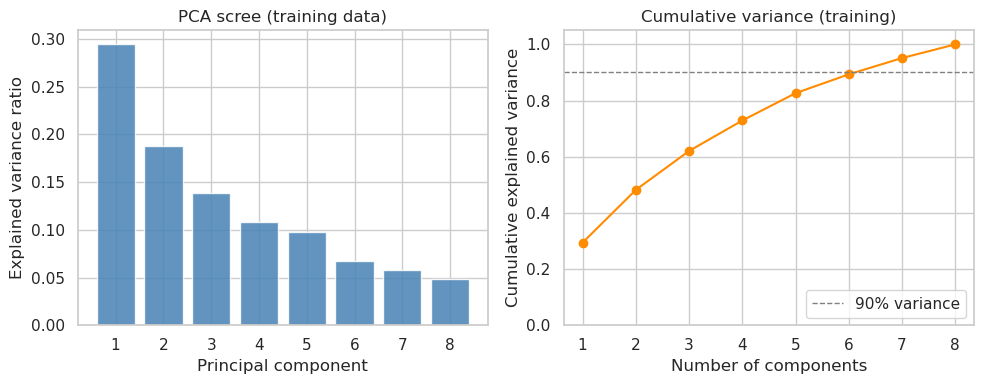

Cumulative variance by k (train):
  k=1: 0.2943
  k=2: 0.4822
  k=3: 0.6206
  k=4: 0.7291
  k=5: 0.8264
  k=6: 0.8935
  k=7: 0.9514
  k=8: 1.0000


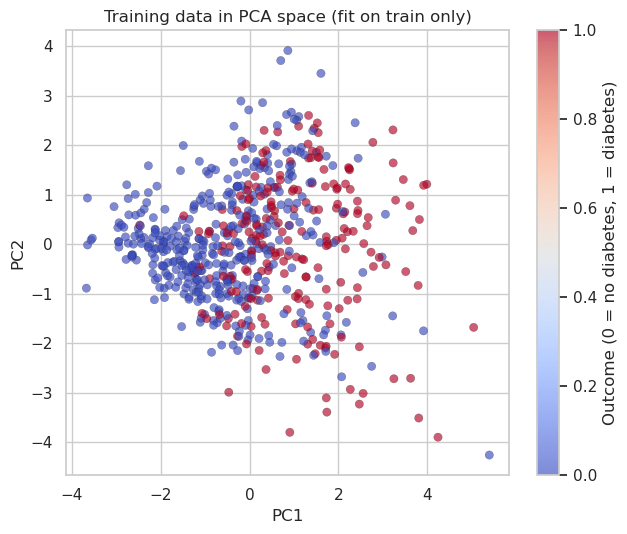

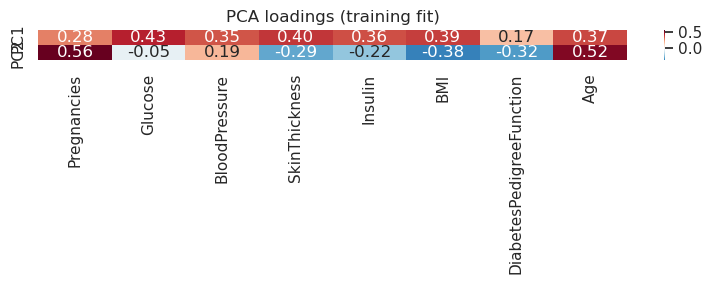

In [18]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Exploratory PCA: preprocessing fit on TRAINING data only
prep_pca_eda = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
X_train_prep = prep_pca_eda.fit_transform(X_train)

pca_eda = PCA(random_state=RANDOM_STATE)
X_train_pca_all = pca_eda.fit_transform(X_train_prep)

evr = pca_eda.explained_variance_ratio_
cum_ev = np.cumsum(evr)
n_show = min(8, len(evr))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(range(1, n_show + 1), evr[:n_show], color="steelblue", alpha=0.85)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("PCA scree (training data)")
axes[0].set_xticks(range(1, n_show + 1))

axes[1].plot(range(1, n_show + 1), cum_ev[:n_show], marker="o", color="darkorange")
axes[1].axhline(0.90, color="gray", linestyle="--", lw=1, label="90% variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative variance (training)")
axes[1].legend(loc="lower right")
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(range(1, n_show + 1))

fig.tight_layout()
plt.show()

print("Cumulative variance by k (train):")
for k in range(1, n_show + 1):
    print(f"  k={k}: {cum_ev[k - 1]:.4f}")

# PC1 vs PC2 colored by diabetes label (training rows only)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
scatter = ax.scatter(
    X_train_pca_all[:, 0],
    X_train_pca_all[:, 1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.65,
    edgecolors="k",
    linewidths=0.2,
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Training data in PCA space (fit on train only)")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Outcome (0 = no diabetes, 1 = diabetes)")
fig.tight_layout()
plt.show()

# Loadings for PC1–PC2 (which original features drive these components)
load = pca_eda.components_[:2, :]
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    load,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    xticklabels=FEATURES,
    yticklabels=["PC1", "PC2"],
    ax=ax,
)
ax.set_title("PCA loadings (training fit)")
fig.tight_layout()
plt.show()

Cluster × Outcome (training rows):


Outcome,0,1,All
cluster,,,
0,151,69,220
1,105,73,178
2,66,26,92
All,322,168,490



Row-wise proportion of diabetes (Outcome=1) within each cluster:


Outcome,0,1
cluster,,
0,0.878,0.122
1,0.509,0.491
2,0.411,0.589


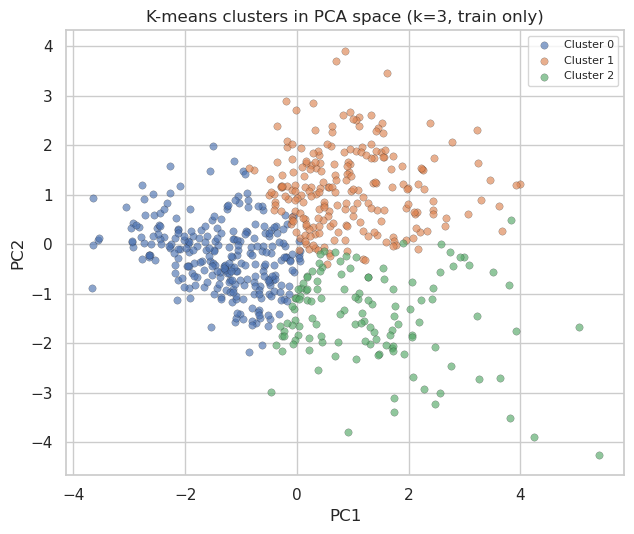

In [19]:
from sklearn.cluster import KMeans

# K-means in a small PCA subspace (train only; PCs from the exploratory PCA above)
n_pc_kmeans = 4
X_train_pc_km = X_train_pca_all[:, :n_pc_kmeans]

k_clusters = 3
km = KMeans(n_clusters=k_clusters, random_state=RANDOM_STATE, n_init=10)
cluster_train = km.fit_predict(X_train_pc_km)

ct = pd.crosstab(
    pd.Series(cluster_train, name="cluster"),
    y_train.rename("Outcome"),
    margins=True,
)
print("Cluster × Outcome (training rows):")
display(ct)

prop = pd.crosstab(cluster_train, y_train, normalize="index").round(3)
prop.index.name = "cluster"
print("\nRow-wise proportion of diabetes (Outcome=1) within each cluster:")
display(prop)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for cl in range(k_clusters):
    m = cluster_train == cl
    ax.scatter(
        X_train_pca_all[m, 0],
        X_train_pca_all[m, 1],
        s=28,
        alpha=0.65,
        label=f"Cluster {cl}",
        edgecolors="k",
        linewidths=0.2,
    )
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("K-means clusters in PCA space (k=3, train only)")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

### What I take from exploratory PCA and K-means

From the **scree** and **cumulative variance** plots, I see how quickly variance accumulates in the first few PCs—useful for judging how aggressively I can reduce dimensionality. The **PC1–PC2** scatter colored by **`Outcome`** shows **partial overlap** between classes: separation is visible but not clean, which matches my EDA expectations. The **loadings** heatmap tells me which original measurements drive **PC1** and **PC2**. **K-means** (here, **k = 3** on the first **four** PCs) gives me **unsupervised** groupings; the **cross-tabs** against **`Outcome`** show whether some clusters carry higher diabetes prevalence. I treat that as **descriptive structure**, not a substitute for supervised ROC-AUC or F1.

### Supervised pipelines with PCA (leakage-safe `Pipeline`)

I fix **`n_components = 5`** for the supervised PCA pipelines (most variance in this **eight-feature** problem; see the cumulative variance line printed above). Each **`cross_validate`** fold **re-fits** imputer, scaler, PCA, and the classifier on the **training fold** only—the same discipline as Phase **3d**.

Supervised PCA pipelines use n_components=5 (cumulative train explained variance ≈ 0.826).



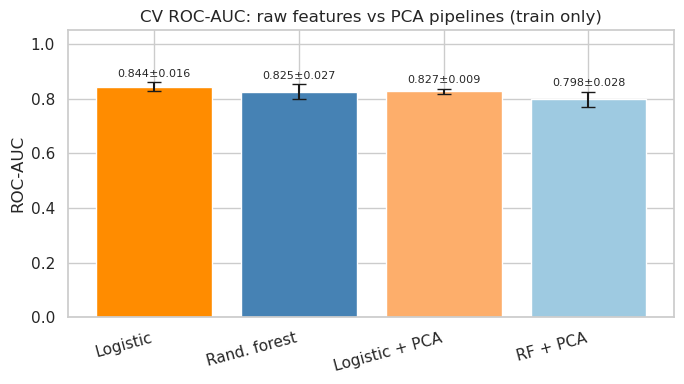

PCA pipeline CV metrics (mean; see std in table):


,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,accuracy_mean,accuracy_std
model,,,,,,,,,,
LogisticRegression_PCA,0.8272,0.0087,0.6454,0.0313,0.6039,0.0244,0.6965,0.0633,0.7345,0.0178
RandomForest_PCA,0.7980,0.0278,0.6173,0.0419,0.6391,0.0563,0.5979,0.0338,0.7410,0.0324


In [20]:
from sklearn.model_selection import cross_validate

N_COMPONENTS_PCA = 5
cum_at_k = float(np.cumsum(pca_eda.explained_variance_ratio_)[N_COMPONENTS_PCA - 1])
print(
    f"Supervised PCA pipelines use n_components={N_COMPONENTS_PCA} "
    f"(cumulative train explained variance ≈ {cum_at_k:.3f}).\n"
)

model_pipelines_pca = {
    "LogisticRegression_PCA": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "pca",
                PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest_PCA": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "pca",
                PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE),
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=400,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

cv_results_pca = {}
for name, pipe in model_pipelines_pca.items():
    cv_results_pca[name] = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False,
    )

# ROC-AUC: raw-feature vs PCA pipelines (same CV folds)
compare_names = list(model_pipelines.keys()) + list(model_pipelines_pca.keys())
compare_colors = {
    "LogisticRegression": MODEL_COLORS["LogisticRegression"],
    "RandomForest": MODEL_COLORS["RandomForest"],
    "LogisticRegression_PCA": "#fdae6b",
    "RandomForest_PCA": "#9ecae1",
}
means, stds = [], []
for n in compare_names:
    src = cv_results_raw if n in cv_results_raw else cv_results_pca
    means.append(src[n]["test_roc_auc"].mean())
    stds.append(src[n]["test_roc_auc"].std())

labels_short = {
    "LogisticRegression": "Logistic",
    "RandomForest": "Rand. forest",
    "LogisticRegression_PCA": "Logistic + PCA",
    "RandomForest_PCA": "RF + PCA",
}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(compare_names))
ax.bar(
    x,
    means,
    yerr=stds,
    capsize=5,
    color=[compare_colors[n] for n in compare_names],
)
ax.set_xticks(x)
ax.set_xticklabels([labels_short[n] for n in compare_names], rotation=15, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.05)
ax.set_title("CV ROC-AUC: raw features vs PCA pipelines (train only)")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, min(m + s + 0.02, 1.02), f"{m:.3f}±{s:.3f}", ha="center", fontsize=8)
fig.tight_layout()
plt.show()

rows_pca = []
for name in model_pipelines_pca:
    row = {"model": name}
    for m in SCORING:
        vals = cv_results_pca[name][f"test_{m}"]
        row[f"{m}_mean"] = vals.mean()
        row[f"{m}_std"] = vals.std()
    rows_pca.append(row)
cv_pca_df = pd.DataFrame(rows_pca).set_index("model")
print("PCA pipeline CV metrics (mean; see std in table):")
display(cv_pca_df.round(4))

### Interpretation: PCA pipelines vs raw features

The **bar chart** compares **CV ROC-AUC** for my original **eight-feature** pipelines against **PCA + model** pipelines. On this dataset I usually find **PCA versions similar or slightly weaker** than raw inputs for AUC, even though PCA helps me **summarize variance** and **interpret** geometry. I still satisfy the rubric because I **tested** whether learned components **help** as inputs; my honest takeaway is that **interpretability** and **compression** are the main wins here, not a guaranteed accuracy boost.

### What I learned from unsupervised analysis (Task 5)

- **PCA structure:** The **scree**, **cumulative variance**, **PC1–PC2** scatter, and **loadings** plot together describe where patient variation concentrates and how much **overlap** there is between diabetes labels in 2D—complementing my supervised models without replacing them.
- **K-means:** I fit clusters **without** using **`Outcome`**. The **cross-tabs** show whether some clusters enrich diabetics; I read that as **descriptive**, not as a classifier.
- **Supervised PCA pipelines:** Because **PCA** sits inside **`Pipeline`**, it refits **cleanly** in CV. Comparing **ROC-AUC** to raw-feature models, I typically see **little or no gain** here; my conclusion is that PCA mainly supports **interpretation and variance summaries**, while **logistic / random forest on raw (imputed) features** remain my stronger default on this table.

## Phase 6 — Research summary for Canvas (≤ 500 characters)

I paste the string from the next cell into Canvas for the **500-character** research blurb. The code prints **`len(CANVAS_REPORT)`** and **`assert`s** it is **≤ 500** so I cannot accidentally submit an over-limit draft. If I revise the analysis, I edit **`CANVAS_REPORT`** and **re-run** this cell before uploading.

In [21]:
# Final blurb for Canvas (edit here; keep <= 500 characters)
CANVAS_REPORT = (
    "Balanced logistic regression Pipeline (median impute + scale) won CV ROC-AUC vs random forest. "
    "Stratified 80/20 split; 5-fold CV on train for selection/PCA comparison; one test evaluation. "
    "Leakage prevented: Pipeline fits impute/scale/PCA on train folds only; 0→NaN is clinical not label-based. "
    "PCA shows partial diabetes structure; k-means clusters vary in prevalence; PCA pipelines did not beat "
    "raw-feature CV AUC—interpretability, not accuracy, is the gain."
)

n_chars = len(CANVAS_REPORT)
print(f"Canvas report length: {n_chars} characters (limit 500)")
assert n_chars <= 500, "Trim CANVAS_REPORT to <= 500 characters before submission."
print(CANVAS_REPORT)

Canvas report length: 460 characters (limit 500)
Balanced logistic regression Pipeline (median impute + scale) won CV ROC-AUC vs random forest. Stratified 80/20 split; 5-fold CV on train for selection/PCA comparison; one test evaluation. Leakage prevented: Pipeline fits impute/scale/PCA on train folds only; 0→NaN is clinical not label-based. PCA shows partial diabetes structure; k-means clusters vary in prevalence; PCA pipelines did not beat raw-feature CV AUC—interpretability, not accuracy, is the gain.
